# Ejercicio Python 1 Construcción de un portafolio eficiente con simulación
# Eduardo Veytia H.

### Evaluar la capacidad para aplicar simulaciones Monte Carlo en la construcción y análisis de portafolios con distintos niveles de riesgo y rendimiento.

### 1. Descarga precios históricos de tres activos financieros distintos El periodo de análisis debe cubrir al menos 3 años.


In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt

[*********************100%***********************]  3 of 3 completed


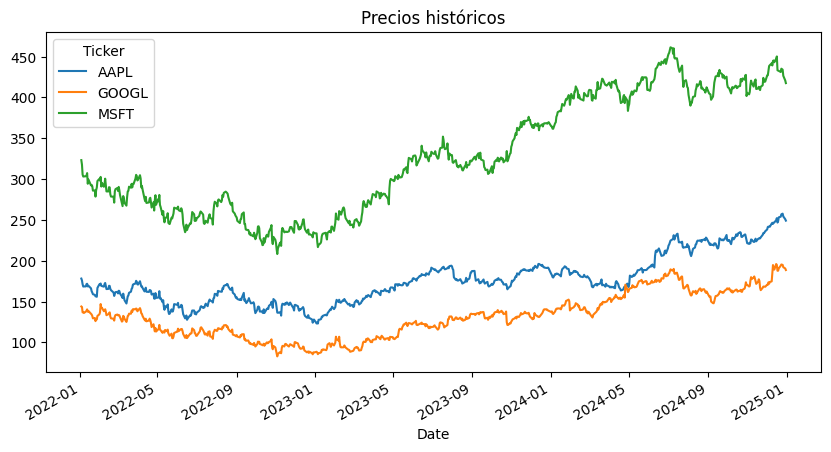

In [2]:
# Descarga de datos
tickers = ["AAPL","MSFT","GOOGL"]

prices = yf.download(tickers, start='2022-01-01', end='2025-01-01')['Close']
prices.plot(figsize=(10,5),title="Precios históricos")
plt.show()

### 2. Calcula los rendimientos diarios y estima sus medias y matriz de covarianzas.

In [3]:
rets = prices.pct_change().dropna()
rets.head()

Ticker,AAPL,GOOGL,MSFT
Date,,,
2022-01-04,-0.012692,-0.004083,-0.017147
2022-01-05,-0.026600,-0.045876,-0.038388
2022-01-06,-0.016693,-0.000200,-0.007902
2022-01-07,0.000988,-0.005303,0.000510
2022-01-10,0.000116,0.012061,0.000732


In [4]:
#media diaria
ret_diario = rets.mean()
#media anual
ret_anual = rets.mean() * 252

ret_diario*100, ret_anual*100

(Ticker
 AAPL     0.059113
 GOOGL    0.057200
 MSFT     0.049123
 dtype: float64,
 Ticker
 AAPL     14.896477
 GOOGL    14.414379
 MSFT     12.379074
 dtype: float64)

In [5]:
vol_anual = rets.std() * np.sqrt(252)
vol_anual*100

Ticker
AAPL     27.093515
GOOGL    32.744064
MSFT     27.576621
dtype: float64

In [6]:
cov = rets.cov()
cov

Ticker,AAPL,GOOGL,MSFT
Ticker,,,
AAPL,0.000291,0.000219,0.000203
GOOGL,0.000219,0.000425,0.000249
MSFT,0.000203,0.000249,0.000302


### 3. Simula al menos 10,000 portafolios conformados por los tres activos, con pesos aleatorios que sumen 1.

### 4. Para cada portafolio, calcula:

**a) Rendimiento esperado.**

**b) Riesgo (desviación estándar).**

**c) Ratio de Sharpe (considera una tasa libre de riesgo de 4% anual).**

In [14]:
n_sim = 10000
n_days = 252
k = len(tickers)

L = np.linalg.cholesky(cov)
portfolio_paths = np.zeros((n_days,n_sim))

In [15]:
p_returns = []
p_volatility = []
p_weights = []
for m in range(n_sim):
    w = np.random.random(k)
    w = w / np.sum(w)
    weights = w
    Z = np.random.normal(size=(n_days,k))
    correlated = Z @ L.T
    daily_returns = correlated + ret_diario.values
    port_daily = daily_returns @ weights
    portfolio_paths[:,m] = np.cumprod(1+port_daily)
    p_weights.append(w)
    p_returns.append(np.sum(ret_anual * w))
    p_volatility.append(np.sqrt(np.dot(w.T, np.dot(cov * 252, w))))

### 5. Grafica el diagrama riesgo–rendimiento con todos los portafolios. En la misma figura:

**a) Identifica el portafolio de menor riesgo.**

**b) Identifica el portafolio de mayor rendimiento.**

**c) Identifica el portafolio con mayor Sharpe.**

In [16]:
# Convertir a arrays
arr_ret = np.array(p_returns)
arr_vol = np.array(p_volatility)
arr_sharpe = arr_ret / arr_vol

# 1. Portafolio de Máximo Sharpe
max_sharpe = arr_sharpe.argmax()
w_max_sharpe = p_weights[max_sharpe]

# 2. Portafolio de Mínima Varianza
min_vol = arr_vol.argmin()
w_min_vol = p_weights[min_vol]

# 3. Portafolio de Máximo Rendimiento
max_ret = arr_ret.argmax()
w_max_ret = p_weights[max_ret]

In [17]:
path_max_sharpe = portfolio_paths[:, max_sharpe]
path_min_vol = portfolio_paths[:, min_vol]
path_max_rend = portfolio_paths[:, max_ret]

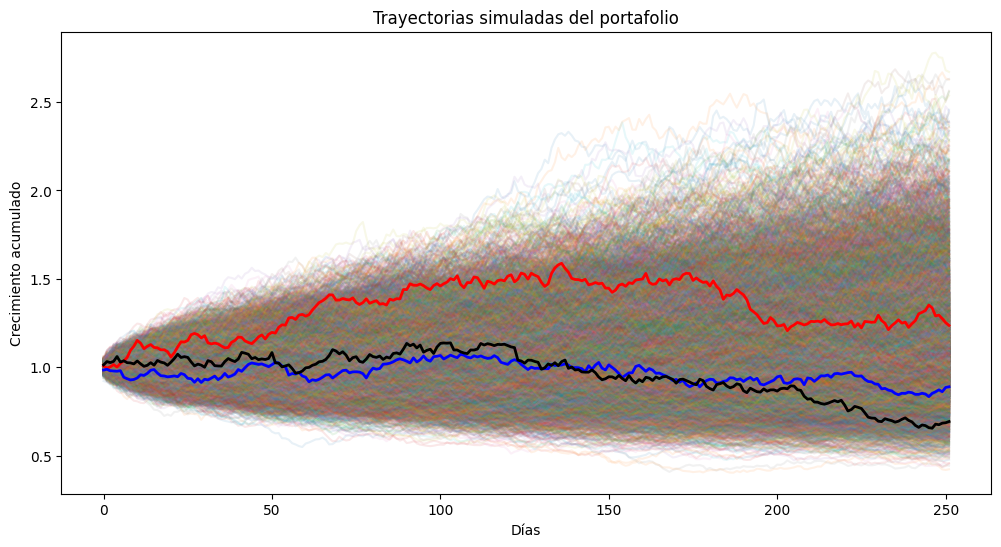

In [18]:
plt.figure(figsize=(12,6))
plt.plot(portfolio_paths,alpha=0.1)
plt.plot(path_max_sharpe, color='red', linewidth=2, label=f'Max Sharpe Ratio')
plt.plot(path_min_vol, color='blue', linewidth=2, label=f'Mínima Volatilidad')
plt.plot(path_max_rend, color='black', linewidth=2, label=f'Max Rend')
plt.title("Trayectorias simuladas del portafolio")
plt.xlabel("Días")
plt.ylabel("Crecimiento acumulado")
plt.show()

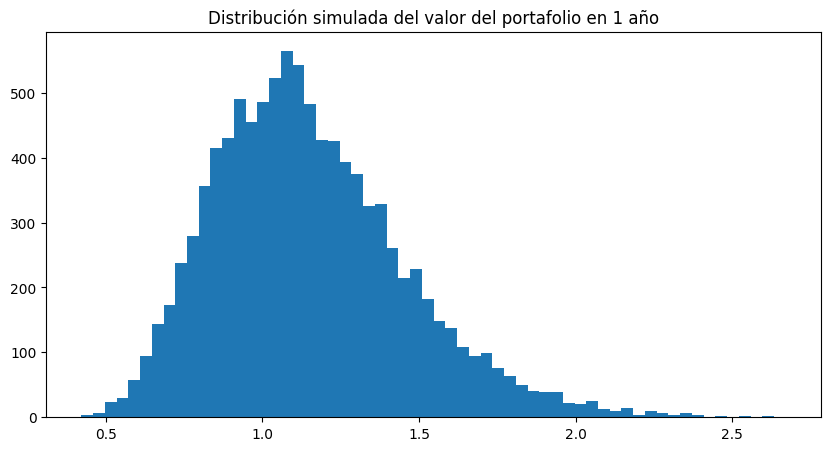

Valor esperado final: 1.1500574526082665
Probabilidad de pérdida: 0.3427


In [19]:
final_values = portfolio_paths[-1]
plt.figure(figsize=(10,5))
plt.hist(final_values,bins=60)
plt.title("Distribución simulada del valor del portafolio en 1 año")
plt.show()
print("Valor esperado final:", final_values.mean())
print("Probabilidad de pérdida:", np.mean(final_values<1))

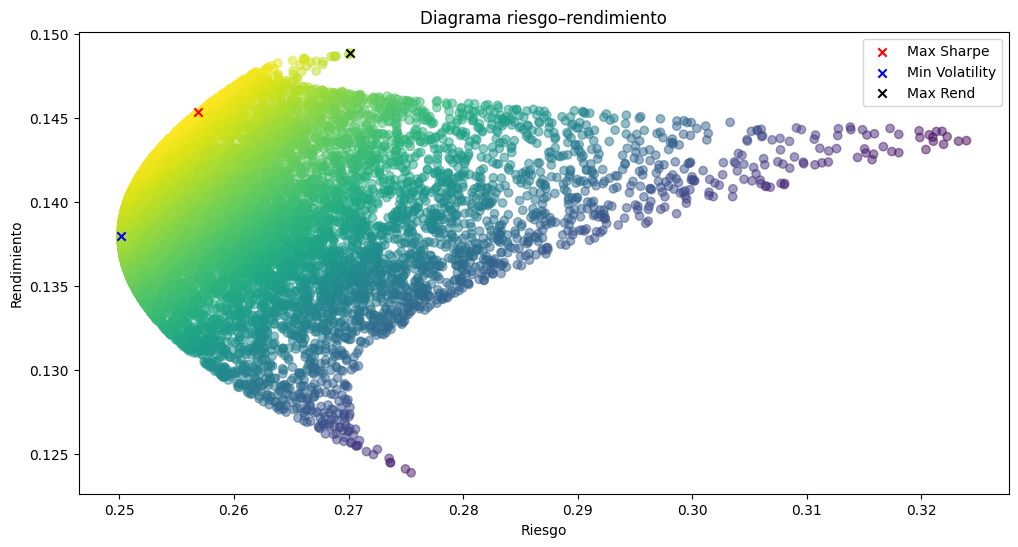

Pesos Max Sharpe: [('AAPL', np.float64(0.704)), ('MSFT', np.float64(0.188)), ('GOOGL', np.float64(0.108))]
Pesos Min Vol: [('AAPL', np.float64(0.5)), ('MSFT', np.float64(0.078)), ('GOOGL', np.float64(0.422))]
Pesos Min Vol: [('AAPL', np.float64(0.988)), ('MSFT', np.float64(0.011)), ('GOOGL', np.float64(0.001))]


In [20]:
# Scatter plot de portafolios aleatorios
plt.figure(figsize=(12, 6))
plt.scatter(arr_vol, arr_ret, c=arr_sharpe, cmap='viridis', alpha=0.5)

# Scatter plot de Maximo de Sharpe
plt.scatter(arr_vol[max_sharpe], arr_ret[max_sharpe], color='red', marker='x', label='Max Sharpe')
# Scatter plot de Minima Varianza
plt.scatter(arr_vol[min_vol], arr_ret[min_vol], color='blue', marker='x', label='Min Volatility')
# Scatter plot de Maximo rendimiento
plt.scatter(arr_vol[max_ret], arr_ret[max_ret], color='black', marker='x', label='Max Rend')

plt.title("Diagrama riesgo–rendimiento")
plt.xlabel("Riesgo")
plt.ylabel("Rendimiento")
plt.legend()
plt.show()

print(f"Pesos Max Sharpe: {list(zip(tickers, w_max_sharpe.round(3)))}")
print(f"Pesos Min Vol: {list(zip(tickers, w_min_vol.round(3)))}")
print(f"Pesos Min Vol: {list(zip(tickers, w_max_ret.round(3)))}")

### 6. Redacta un breve análisis, usando markdown en tu notebook, explicando qué portafolio recomendarías y por qué.

Tras realizar la simulación de 10,000 portafolios mediante el método de Monte Carlo, he identificado tres perfiles clave:

**Portafolio de Mínima Varianza (Azul):** Busca reducir las sacudidas del mercado al mínimo. 

**Portafolio de Máximo Rendimiento (Negro):** Se enfoca solo en el resultado final, sin importar qué tan volátil (riesgoso) sea el camino. Lo recomendaría solo para inversionistas con mucha tolerancia al riesgo y un horizonte de tiempo largo.

**Portafolio de Máximo Sharpe (Rojo):** Este es el que yo recomendaría personalmente.

**¿Por qué el de Máximo Sharpe?** Es el más eficiente. Este portafolio ofrece el mejor equilibrio: nos da la mayor cantidad de rendimiento por cada unidad de riesgo que estamos aceptando. 
